# STAT 7220 - Midterm Exam
## Dr. Austin R. Brown
### School of Data Science & Analytics
### Kennesaw State University

**DUE: March 6, 2026**

**PART 1 INSTRUCTIONS:** Suppose you are a video game controller manufacturer interested in estimating the perceived comfort level of controller grips. To achieve this, you decide to conduct an experiment to assess different material types used for the controller grips (plastic, rubber, silicone, and metal). 10 prototypes of each grip type are manufactured and given to professional gamers (who all play the same game -- Apex Legends) to test. The gamers use the controllers regularly for one month and then rate the comfort level on a scale from 1 - 10 with greater scores indicating a greater level of perceived comfort (one decimal allowed). The data from this experiment are stored in the Video Game Controllers.xlsx file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

The objective of this experiment is to determine whether the type of grip material (plastic, rubber, silicone, or metal) affects the perceived comfort level of video game controllers after one month of regular use.

**Question 2.** Specify the outcome variable

The outcome variable is the comfort rating score (1-10 scale, one decimal allowed), representing perceived comfort.

**Question 3.** Specify the independent variable. What are some possible lurking variables?

Independent Variable includes Grip material type (plastic, rubber, silicone, metal)
Possible Lurking Variables includes hand size of gamers, grip strength, hours played per week, personal material preference, temperature/sweat during gameplay, and controller weight differences.

**Question 4.** Briefly explain why a completely randomized design may be appropriate for this experiment.

A completely randomized design is appropriate because professional gamers are assumed to be relatively similar in skill level and all play the same game. Randomly assigning controllers helps ensure that differences in comfort ratings are due to grip material rather than other uncontrolled factors.

**Question 5.** State the null and alternative hypotheses for this experiment.

Null Hypothesis (H₀): All mean comfort ratings are equal.
Alternative Hypothesis (Hₐ): At least one material has a different mean comfort rating.

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?



In [9]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "MihretTe"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
   print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
       print(f"📥 Cloning repo from {repo_url}...")
       os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
   print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
   print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Assignments/Midterm-Exam"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/MihretTe/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/Midterm-Exam/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/MihretTe/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/Midterm-Exam/STAT-7220-Applied-Experimental-Design/Assignments/Midterm-Exam


Summary Statistics by Material:
          Mean  Median   Std_Dev  Min  Max  Count
Material                                         
Metal     5.39    5.25  0.877433  4.0  6.5     10
Plastic   5.93    5.95  0.620125  4.6  6.8     10
Rubber    6.23    6.40  0.702456  4.9  7.5     10
Silicone  7.63    7.90  0.700872  6.6  8.4     10


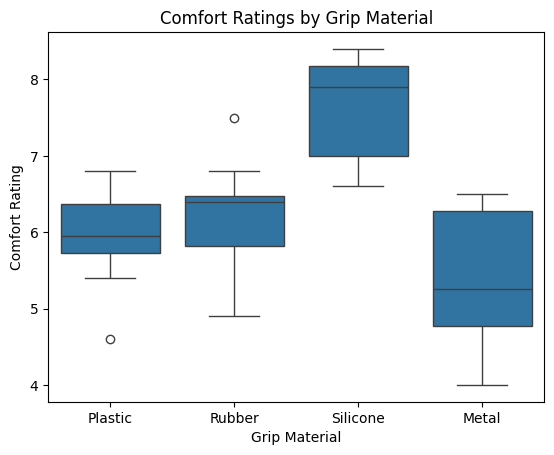

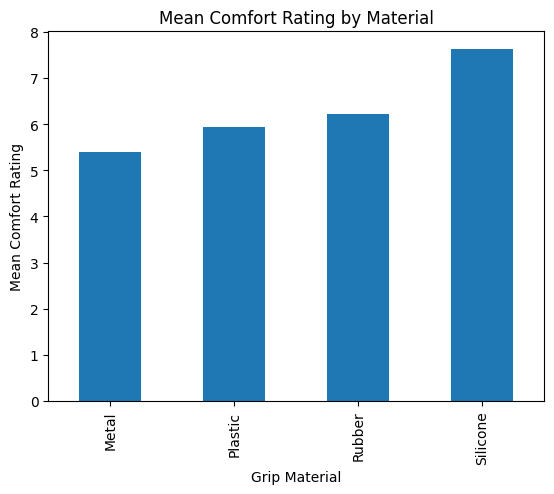

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_excel("Video Game Controllers.xlsx")

# -----------------------------
# Summary Statistics
# -----------------------------
summary_stats = df.groupby("Material")["Comfort"].agg(
    Mean="mean",
    Median="median",
    Std_Dev="std",
    Min="min",
    Max="max",
    Count="count"
)

print("Summary Statistics by Material:")
print(summary_stats)

# -----------------------------
# Boxplot
# -----------------------------
plt.figure()
sns.boxplot(x="Material", y="Comfort", data=df)
plt.title("Comfort Ratings by Grip Material")
plt.xlabel("Grip Material")
plt.ylabel("Comfort Rating")
plt.show()

# -----------------------------
# Mean Comparison Bar Chart
# -----------------------------
means = df.groupby("Material")["Comfort"].mean()

plt.figure()
means.plot(kind="bar")
plt.title("Mean Comfort Rating by Material")
plt.xlabel("Grip Material")
plt.ylabel("Mean Comfort Rating")
plt.show()

he results of this exploratory analysis more strongly support the alternative hypothesis ($H_a$). While the null hypothesis ($H_0$) assumes all mean comfort ratings are equal ($\mu_1 = \mu_2 = \mu_3 = \mu_4$), the data shows a substantial difference between groups. Notably, silicone has a mean rating of 7.63, which is 2.24 points higher than metal (5.39). This significant "visual gap" in the boxplot suggests that the grip material likely has a genuine effect on comfort rather than the results being due to random chance.

**Question 7.** Build a one-way ANOVA model. Test the assumption of normality using **both** a testing and visual method. Do the results of the normality test(s) support the assumption of normality?



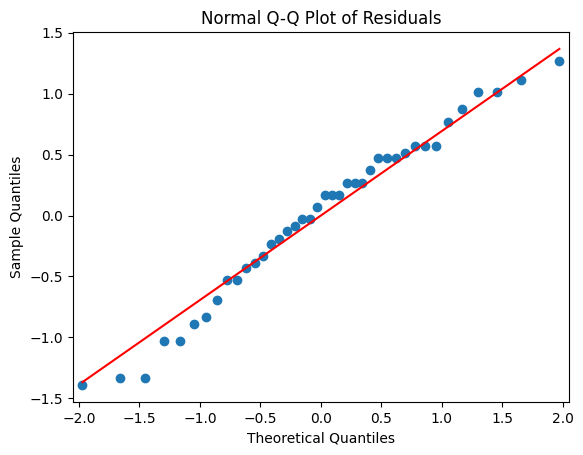

Shapiro-Wilk Test: Statistics=0.9710, p-value=0.3874


In [11]:
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 1. Build the One-Way ANOVA model
model = ols('Comfort ~ C(Material)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

# 2. Extract residuals for normality testing
residuals = model.resid

# 3. Visual Method: Q-Q Plot
fig = sm.qqplot(residuals, line='s')
plt.title("Normal Q-Q Plot of Residuals")
plt.show()

# 4. Testing Method: Shapiro-Wilk Test
shapiro_test = stats.shapiro(residuals)
print(f"Shapiro-Wilk Test: Statistics={shapiro_test.statistic:.4f}, p-value={shapiro_test.pvalue:.4f}")

The results of the normality tests support the assumption of normality for the ANOVA model. The Shapiro-Wilk test yielded a p-value of 0.3874, which is well above the common significance level of 0.05; therefore, we fail to reject the null hypothesis that the residuals are normally distributed. This statistical finding is reinforced by the Normal Q-Q Plot, where the data points closely follow the straight diagonal reference line with no significant departures or heavy-tail patterning. Because both the visual and testing methods align, the assumption of normality is satisfied.

**Question 8.** Test the assumption of homogeneity of variance using **both** a testing and visual method. Do the results of the test(s) support the assumption of homogeneity of variance?



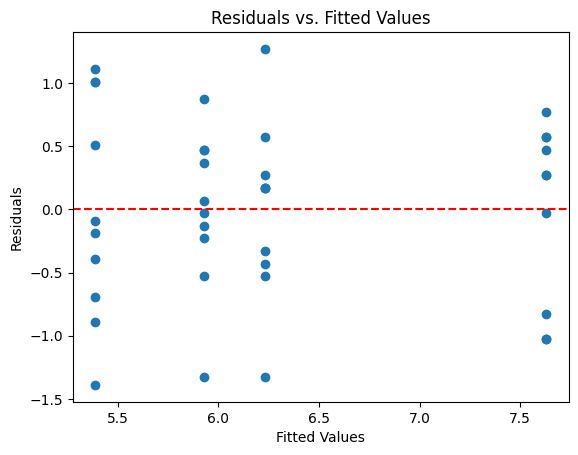

Levene's Test: Statistics=0.5785, p-value=0.6329


In [12]:
# 1. Visual Method: Residuals vs. Fitted Plot
plt.figure()
plt.scatter(model.fittedvalues, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Residuals vs. Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

# 2. Testing Method: Levene's Test
# We use Levene's test because it is more robust to slight departures from normality than Bartlett's test.
levene_test = stats.levene(df['Comfort'][df['Material'] == 'Metal'],
                           df['Comfort'][df['Material'] == 'Plastic'],
                           df['Comfort'][df['Material'] == 'Rubber'],
                           df['Comfort'][df['Material'] == 'Silicone'])

print(f"Levene's Test: Statistics={levene_test.statistic:.4f}, p-value={levene_test.pvalue:.4f}")

The Levene’s test yielded a p-value of 0.6329, which is significantly higher than the standard alpha level of 0.05. This indicates that we fail to reject the null hypothesis, meaning the variances across the four material groups are not significantly different from one another. This statistical finding is visually corroborated by the Residuals vs. Fitted Values plot, which shows a relatively consistent vertical spread (or "thickness") of points across the different fitted values. Since the spread of the residuals does not change systematically, the constant variance assumption is satisfied.

**Question 9.** Report the F-statistic and its associated p-value for the test for the treatment factor. Which of our two hypotheses is more strongly supported? Why?



In [13]:
# Display the ANOVA table results
print(anova_table)

             sum_sq    df          F        PR(>F)
C(Material)  27.387   3.0  17.070642  4.616153e-07
Residual     19.252  36.0        NaN           NaN


The results strongly support the alternative hypothesis ($H_a$). The ANOVA model yielded an F-statistic of 17.07 and a p-value of $4.616 \times 10^{-7}$, which is far below the significance level of 0.05. This extremely low p-value indicates that the probability of observing such large differences in comfort scores by random chance is nearly zero, suggesting that the grip material has a significant effect on perceived comfort.

**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which material types are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.



 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2  meandiff p-adj   lower  upper  reject
------------------------------------------------------
  Metal  Plastic     0.54 0.3639 -0.3408 1.4208  False
  Metal   Rubber     0.84 0.0662 -0.0408 1.7208  False
  Metal Silicone     2.24    0.0  1.3592 3.1208   True
Plastic   Rubber      0.3 0.7958 -0.5808 1.1808  False
Plastic Silicone      1.7    0.0  0.8192 2.5808   True
 Rubber Silicone      1.4 0.0007  0.5192 2.2808   True
------------------------------------------------------


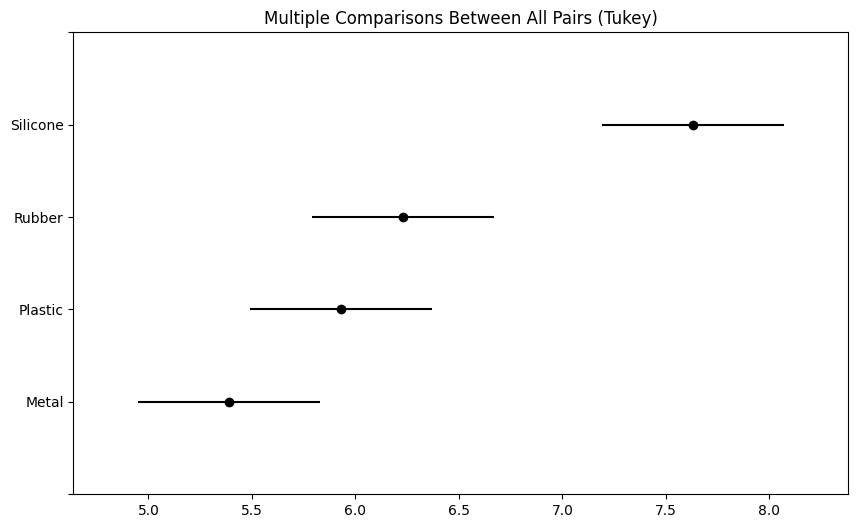

In [14]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey's HSD post-hoc test
tukey = pairwise_tukeyhsd(endog=df['Comfort'],
                          groups=df['Material'],
                          alpha=0.05)

# Display the summary table
print(tukey)

# Optional: Plot the results to visualize confidence intervals
tukey.plot_simultaneous()
plt.show()

The Tukey's HSD post-hoc test reveals that Silicone is significantly more comfortable than all other tested materials (Metal, Plastic, and Rubber), as evidenced by the "True" status in the reject column for all Silicone pairings. Conversely, there were no statistically significant differences found between Metal, Plastic, and Rubber. This suggests that while Silicone stands out as a superior material for grip comfort, the other three materials provide a statistically comparable user experience.
A post-hoc test would not be appropriate if the initial ANOVA failed to support the alternative hypothesis. Since the null hypothesis ($H_0$) assumes all group means are equal, a non-significant p-value ($p > 0.05$) indicates that any observed differences are likely due to random chance rather than the treatment effect

**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses. Additionally, include potential limitations of this experiment and suggestions for future experimentation.



The experiment indicates that grip material significantly impacts controller comfort ($F = 17.07$, $p < 0.001$). Silicone is the most effective material, providing a statistically higher comfort level (Mean = 7.63) than Metal, Plastic, and Rubber. While minor differences exist between the other three materials, they are not statistically significant, making silicone the clear choice for maximizing user comfort.Limitations & Future ResearchLimitations: The study focused exclusively on professional gamers playing Apex Legends, which may not represent casual users or different game genres. Additionally, it did not account for long-term wear or environmental factors like hand temperature and sweat.Future Suggestions: Future research should include a more diverse participant pool and test the materials over a longer duration (6+ months) to evaluate how durability affects comfort over time.

**PART 2 INSTRUCTIONS:** The same video game controller manufacturing company is now trying to get into the business of creating virtual reality/artificial intelligence content for education. Specifically, they want to build a VR experience to simulate working with elderly patients at a healthcare facility to better prepare nursing students for potential careers in working with elderly patients. To test the VR's effectiveness, a group of 40 undergraduate nursing students were randomly and equally assigned to either a class session utilizing the VR or a class session using a traditional technique for teaching strategies for working with elderly patients. At the end of the class session, a 50 question quiz was given to both groups which measures attitudes toward elderly people. Scores range from 0-50 with greater scores indicating more favorable attitudes toward elderly people and vice versa. However, some students in the group have had prior working experience with elderly people which may have an effect on the quiz outcome. So in the experiment, we document which students have had prior working experience with elderly people and which haven't. The results of the experiment are contained in the `Nursing VR Study.xlsx` file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment




The objective of this experiment is to evaluate the effectiveness of a Virtual Reality (VR) simulation compared to traditional teaching methods in improving the attitudes of undergraduate nursing students toward elderly patients. Additionally, the study aims to account for the potential influence of students' prior work experience with the elderly to ensure a more accurate assessment of the VR's impact on quiz performance.

**Question 2.** Specify the outcome variable




The outcome variable is the quiz score, which measures students' attitudes toward elderly people. The scores range from 0 to 50, with higher values indicating a more favorable or positive attitude and lower values indicating a less favorable attitude.

**Question 3.** Specify the independent variable and blocking factor. What are some possible lurking variables?




The independent variable is the Teaching Method, which consists of two levels: the Virtual Reality (VR) Simulation and the Traditional Technique. The blocking factor is Prior Work Experience with elderly patients (categorized as "Yes" or "No"). This is treated as a block because students with professional experience are expected to have different baseline attitudes or knowledge compared to those without it, regardless of the teaching method used. Potential lurking variables that could still influence the quiz scores include the students' overall academic ability (GPA), their personal relationships with elderly family members outside of a work context, and the specific instructor's teaching style during the sessions.


**Question 4.** Briefly explain why a randomized block design would be appropriate here. Similarly, explain why a completely randomized design would not be appropriate.

A Randomized Block Design (RBD) is appropriate here because it allows us to control for the known "nuisance" variable of prior work experience. By grouping students into blocks based on their experience before randomly assigning them to a teaching method, we reduce the experimental error (noise) and can more clearly see the actual effect of the VR technology.

Conversely, a Completely Randomized Design (CRD) would not be appropriate because it ignores the significant influence of prior experience. If one group (e.g., the VR group) accidentally ended up with a majority of students who already had years of nursing home experience, their higher quiz scores might be attributed to the VR simulation when they actually resulted from their previous background. A CRD would leave this "background noise" in the error term, potentially masking the true effectiveness of the teaching methods.


**Question 5.** State the null and alternative hypotheses for this experiment.




For the Treatment (Teaching Method):Null Hypothesis ($H_0$): There is no difference in the mean quiz scores between the Virtual Reality simulation and the traditional teaching technique ($\mu_{VR} = \mu_{Trad}$).Alternative Hypothesis ($H_a$): There is a significant difference in the mean quiz scores between the Virtual Reality simulation and the traditional teaching technique ($\mu_{VR} \neq \mu_{Trad}$).For the Blocking Factor (Prior Experience):Null Hypothesis ($H_{0-block}$): The mean quiz scores are the same for students with prior work experience and those without it.Alternative Hypothesis ($H_{a-block}$): Students with prior work experience have significantly different mean quiz scores than those without it.

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?



Summary Statistics for Nursing VR Study:
                                 mean       std  count
Method      Experience                                
Traditional No Prior Experience  30.7  4.691600     10
            Prior Experience     30.9  8.556349     10
VR          No Prior Experience  37.3  7.916930     10
            Prior Experience     39.7  6.056218     10


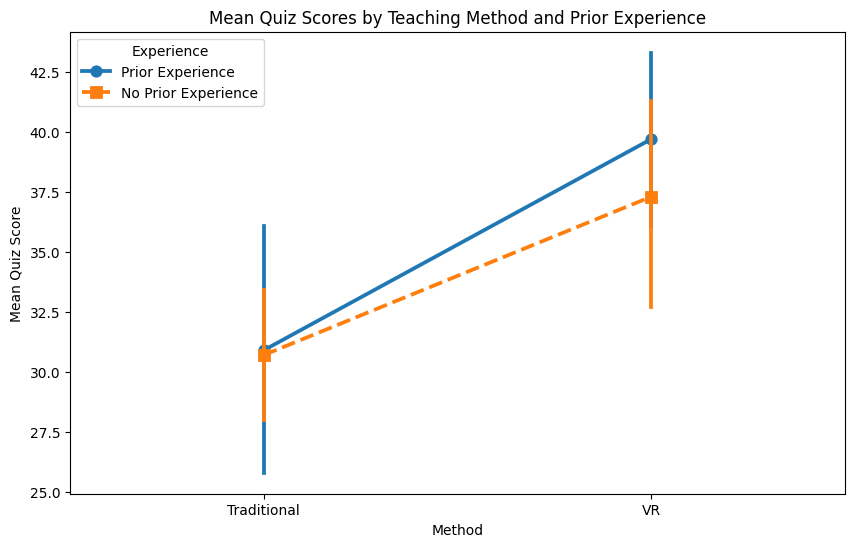

In [19]:
# 1. Summary Statistics grouped by Method and Experience
summary_vr = df_vr.groupby(['Method', 'Experience'])['Score'].agg(['mean', 'std', 'count'])
print("Summary Statistics for Nursing VR Study:")
print(summary_vr)

# 2. Interaction Plot (Visualizing Treatment + Block)
plt.figure(figsize=(10, 6))
sns.pointplot(data=df_vr, x='Method', y='Score', hue='Experience', markers=['o', 's'], linestyles=['-', '--'])
plt.title("Mean Quiz Scores by Teaching Method and Prior Experience")
plt.ylabel("Mean Quiz Score")
plt.show()

Based on the exploratory analysis, the results more strongly support the alternative hypothesis ($H_a$).The summary statistics show a substantial increase in mean quiz scores for the VR group (37.3–39.7) compared to the Traditional group (30.7–30.9). This performance gap of roughly 7 to 9 points is consistent across both experience levels, suggesting that the Virtual Reality simulation is more effective at improving student attitudes than traditional methods. Furthermore, the higher mean for students with prior experience in the VR group confirms that Experience is a significant factor, validating your decision to use a Randomized Block Design to control for this variable.

**Question 7.** Build a two-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?



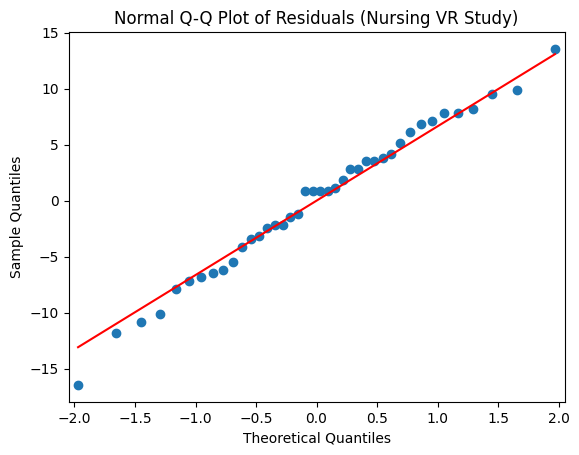

Shapiro-Wilk Test: Statistics=0.9869, p-value=0.9173


In [20]:
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt

# 1. Load the specific data for Part 2
# Ensure the file name matches exactly what is in your Colab file folder
df_vr = pd.read_excel("Nursing VR Study.xlsx")

# 2. Build the Two-Way ANOVA model (Randomized Block Design)
# Teaching Method is the treatment, Experience is the blocking factor
model_vr = ols('Score ~ C(Method) + C(Experience)', data=df_vr).fit()
anova_table_vr = sm.stats.anova_lm(model_vr, typ=2)

# 3. Extract Residuals for testing
residuals_vr = model_vr.resid

# 4. Visual Method: Q-Q Plot
fig = sm.qqplot(residuals_vr, line='s')
plt.title("Normal Q-Q Plot of Residuals (Nursing VR Study)")
plt.show()

# 5. Testing Method: Shapiro-Wilk Test
shapiro_vr = stats.shapiro(residuals_vr)
print(f"Shapiro-Wilk Test: Statistics={shapiro_vr.statistic:.4f}, p-value={shapiro_vr.pvalue:.4f}")

The results of the normality tests support the assumption of normality for the randomized block design. The Shapiro-Wilk test yielded a p-value of 0.9173, which is well above the 0.05 threshold, meaning we fail to reject the null hypothesis that the residuals are normally distributed. This is visually confirmed by the Normal Q-Q Plot, where the data points align tightly with the diagonal reference line. Because both the statistical and visual methods are in agreement, the normality assumption is satisfied, and we can reliably proceed with the ANOVA results.

**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?



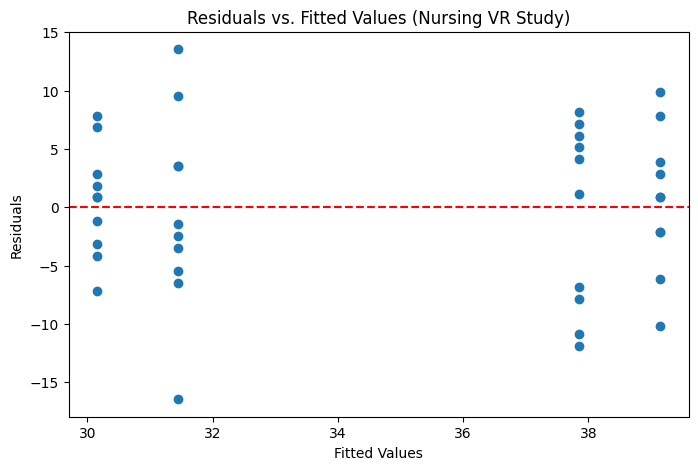

Levene's Test (Method): Statistics=0.1955, p-value=0.6609


In [21]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Visual Method: Residuals vs. Fitted Plot
plt.figure(figsize=(8, 5))
plt.scatter(model_vr.fittedvalues, residuals_vr)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Residuals vs. Fitted Values (Nursing VR Study)")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

# 2. Testing Method: Levene's Test
# We compare the variance between the Traditional and VR groups
levene_vr = stats.levene(df_vr['Score'][df_vr['Method'] == 'Traditional'],
                         df_vr['Score'][df_vr['Method'] == 'VR'])

print(f"Levene's Test (Method): Statistics={levene_vr.statistic:.4f}, p-value={levene_vr.pvalue:.4f}")

The results of the tests support the assumption of homogeneity of variance. The Levene's test resulted in a p-value of 0.6609, which is well above 0.05, indicating that the variances of the quiz scores are statistically similar across the teaching methods. This is visually confirmed by the Residuals vs. Fitted Values plot, where the vertical spread of residuals remains consistent across the fitted values. Since both the statistical test and the visual inspection align, the constant variance assumption is satisfied.

**Question 9.** Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?



In [22]:
# Display the ANOVA table for the Nursing VR Study
print(anova_table_vr)

               sum_sq    df          F    PR(>F)
C(Method)       592.9   1.0  12.441048  0.001140
C(Experience)    16.9   1.0   0.354619  0.555135
Residual       1763.3  37.0        NaN       NaN


The results strongly support the alternative hypothesis ($H_a$). The p-value associated with the teaching method (Treatment) is 0.0011, which is significantly less than the standard alpha level of 0.05. This indicates that we reject the null hypothesis and conclude that the teaching method has a statistically significant effect on quiz scores.

**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.



In [23]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey's HSD post-hoc test for the 'Method' factor
tukey_vr = pairwise_tukeyhsd(endog=df_vr['Score'],
                             groups=df_vr['Method'],
                             alpha=0.05)

# Display the summary table
print(tukey_vr)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
   group1   group2 meandiff p-adj lower   upper  reject
-------------------------------------------------------
Traditional     VR      7.7 0.001 3.3184 12.0816   True
-------------------------------------------------------


Because the data more strongly supported the alternative hypothesis, a Tukey’s HSD post-hoc test was performed. The results indicate a statistically significant difference between the Traditional and Virtual Reality (VR) teaching methods ($p = 0.001$). The mean difference of 7.7 points confirms that the VR group achieved significantly higher scores on the attitude quiz than the traditional group. Since there are only two levels in this treatment effect, this test confirms that the VR simulation is the superior method for improving student attitudes toward elderly patients.

**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses, including potential limitations of this experiment and suggestions for future experimentation.



The results of this experiment demonstrate that the Virtual Reality (VR) simulation is a significantly more effective teaching tool for improving nursing students' attitudes toward elderly patients than traditional methods. The two-way ANOVA revealed a statistically significant treatment effect ($F = 12.44, p = 0.0011$), and the subsequent Tukey HSD test confirmed that the VR group achieved scores that were, on average, 7.7 points higher than the traditional group. While the blocking factor, Prior Experience, was included to control for potential baseline differences, it did not show a statistically significant independent effect on quiz outcomes ($p = 0.5551$). This suggests that the benefits of the VR simulation are robust across students regardless of their previous work history.Despite these positive findings, the study has certain limitations that should be addressed in future research. The sample size of 40 students is relatively small, which may limit the generalizability of the results to the broader nursing student population. Additionally, because the quiz was administered immediately following the session, the data only reflects short-term attitude shifts and does not account for long-term retention or how these attitudes translate into actual clinical practice. To build on these findings, future experiments should include longitudinal follow-up assessments to measure the persistence of these attitude changes over several months. Furthermore, incorporating clinical observations or behavioral metrics would help determine if improved quiz scores lead to better bedside manner and more empathetic care in real-world healthcare settings.

**PART 3 INSTRUCTIONS:** Please briefly respond to the following questions:

**Question 1.** Give a reason why one-factor CRD wouldn't generally be appropriate for studies involving human participants.

Humans have high individual variability (e.g., age, experience, genetics). A CRD fails to control for these, allowing this "noise" to inflate experimental error and potentially mask the true effect of the treatment.


**Question 2.** What is the purpose of post-hoc tests?

Post-hoc tests (like Tukey's HSD) are used after a significant ANOVA to perform pairwise comparisons. They determine exactly which specific groups differ from one another while controlling the overall Type I error rate.



**Question 3.** Explain the difference between RBD and LSD.

A Randomized Block Design (RBD) accounts for one nuisance/blocking factor (e.g., Experience). A Latin Square Design (LSD) accounts for two nuisance factors simultaneously (arranged in rows and columns), requiring the number of levels for all factors to be equal.


**Question 4.** Explain why randomization is important in designing experiments.

Randomization averages out the effects of uncontrolled lurking variables across all groups. This ensures that any observed differences in the outcome are likely due to the treatment rather than systematic bias in how participants were assigned.


**Question 5.** Explain why replication is important in designing experiments.

Replication involves applying the treatment to multiple experimental units. It is essential for estimating experimental error and increasing the precision of the experiment, which allows for more reliable statistical conclusions.
